# Évaluation Single-Task — KMeans (Dataset 2 — Equipment Monitoring)

| Paramètre | Valeur |
|-----------|--------|
| **Modèle** | KMeans Anomaly Detector (`KMeansDetector`) |
| **Dataset** | Equipment Monitoring (Dataset 2) — tous équipements fusionnés |
| **Scénario** | Single-task, entraînement **batch non-supervisé** |
| **Évaluation** | Post-hoc prequential + contribution des variables |
| **Expérience** | `exp_033_kmeans_monitoring_single_task` |
| **Sprint** | S11 |

**Note** : KMeans est un modèle **non-supervisé** — les labels ne sont jamais utilisés à l'entraînement (`fit_task`),  
uniquement en évaluation (accuracy, AUC-ROC). Le seuil est calculé au percentile 95 des distances sur le train set.

In [1]:
# Section 1 — Setup & imports
import json
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import yaml
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.decomposition import PCA

from src.data.monitoring_dataset import get_monitoring_dataloaders_single_task
from src.evaluation.feature_importance import (
    feature_masking_importance,
    permutation_importance,
    plot_feature_importance,
    plot_feature_importance_comparison,
)
from src.models.unsupervised.kmeans_detector import KMeansDetector
from IPython.display import display, Image

MODEL_NAME    = "KMeans"
COLOR         = "#FF9800"
EXP_DIR       = REPO_ROOT / "experiments" / "exp_033_kmeans_monitoring_single_task"
FIGURES_DIR   = REPO_ROOT / "notebooks" / "figures" / "cl_evaluation" / "kmeans" / "monitoring" / "single_task"
CSV_PATH      = REPO_ROOT / "data" / "raw" / "equipment_monitoring" / "Industrial_Equipment_Monitoring_Dataset" / "equipment_anomaly_data.csv"
FEATURE_NAMES = ["temperature", "pressure", "vibration", "humidity"]
SEED          = 42

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(SEED)

print(f"Repo root : {REPO_ROOT}")
print(f"CSV exists: {CSV_PATH.exists()}")

Repo root : /home/leonard/Documents/ENAC/cl-embedded
CSV exists: True


## Section 2 — Métriques batch pré-calculées (exp_033)

In [2]:
metrics_path = EXP_DIR / "results" / "metrics_single_task.json"
if metrics_path.exists():
    with open(metrics_path) as f:
        batch_metrics = json.load(f)
    print("Métriques exp_033 :")
    for k, v in batch_metrics.items():
        print(f"  {k:30s}: {v}")
else:
    print(f"[WARN] {metrics_path} introuvable")
    batch_metrics = {}

Métriques exp_033 :
  exp_id                        : exp_033_kmeans_monitoring_single_task
  model                         : kmeans
  accuracy                      : 0.9550488599348534
  f1                            : 0.7088607594936709
  auc_roc                       : 0.9820616138399402
  ram_peak_bytes                : 5410
  inference_latency_ms          : 0.5692968402217957
  n_params                      : 12


## Section 3 — Résumé visuel des métriques

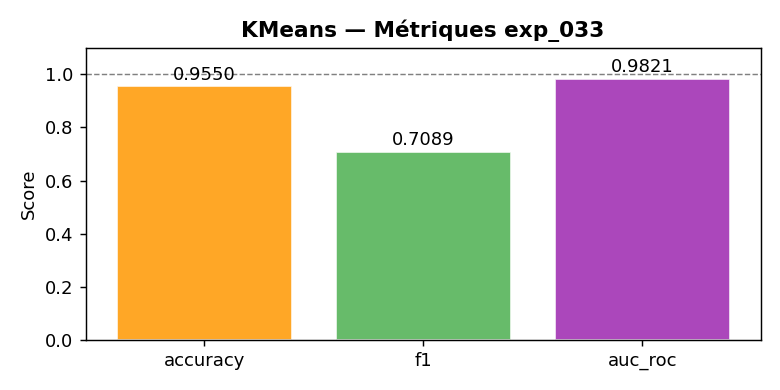

In [3]:
if batch_metrics:
    fig, ax = plt.subplots(figsize=(6, 3), dpi=130)
    metric_keys = ["accuracy", "f1", "auc_roc"]
    vals = [batch_metrics.get(k, 0) for k in metric_keys]
    bars = ax.bar(metric_keys, vals, color=[COLOR, "#4CAF50", "#9C27B0"], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.4f}", ha="center", va="bottom", fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_title(f"{MODEL_NAME} — Métriques exp_033", fontweight="bold")
    ax.set_ylabel("Score")
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "batch_metrics.png", dpi=130)
    display(Image(str(FIGURES_DIR / "batch_metrics.png")))

## Section 4 — Chargement des données et entraînement

In [4]:
assert CSV_PATH.exists(), f"CSV introuvable : {CSV_PATH}"

data = get_monitoring_dataloaders_single_task(
    csv_path=CSV_PATH,
    batch_size=256,
    test_ratio=0.2,
    val_ratio=0.1,
    seed=SEED,
)

def loader_to_numpy(loader):
    Xs, ys = [], []
    for x_batch, y_batch in loader:
        Xs.append(x_batch.numpy())
        ys.append(y_batch.numpy())
    return np.concatenate(Xs).squeeze(), np.concatenate(ys).squeeze()

X_train, y_train = loader_to_numpy(data["train_loader"])
X_test,  y_test  = loader_to_numpy(data["test_loader"])

print(f"Train : {X_train.shape}, faulty={y_train.mean():.3f}")
print(f"Test  : {X_test.shape},  faulty={y_test.mean():.3f}")

# Charger la config kmeans depuis le snapshot
with open(EXP_DIR / "config_snapshot.yaml") as f:
    cfg = yaml.safe_load(f)
cfg_kmeans = cfg["kmeans"]

# Entraînement batch non-supervisé (labels exclus)
model = KMeansDetector(cfg_kmeans)
model.fit_task(X_train.astype(np.float32), task_id=0)
print(f"\n{model.summary()}")

✅ Seed fixé à 42
Train : (5523, 4), faulty=0.100
Test  : (1535, 4),  faulty=0.100
  [KMeans] Tâche 0 — K sélectionné : 3 (méthode=silhouette)
  [KMeans] Seuil calculé sur Task 0 : 3.5331 (percentile 95)

KMeansDetector | k=3 | method=silhouette | threshold=3.5331 | strategy=refit | params=12


## Section 5 — Évaluation prequential simulée

KMeans est un modèle **batch non-supervisé** — il n'y a pas de mise à jour online native.  
L'entraînement est effectué en une passe sur le train set complet (Section 4).  
On évalue ici la qualité des prédictions sur le stream de train **post-hoc** (modèle déjà entraîné),  
ce qui donne une courbe de stabilité sur la distribution d'entraînement.

In [5]:
all_preds: list[int] = []
for xi in X_train:
    pred = int(model.predict(xi.astype(np.float32).reshape(1, -1))[0])
    all_preds.append(pred)

preds_arr  = np.array(all_preds)
labels_arr = y_train.astype(int)
train_acc  = float(np.mean(preds_arr == labels_arr))
print(f"Accuracy sur stream train (post-hoc) : {train_acc:.4f}")

Accuracy sur stream train (post-hoc) : 0.9497


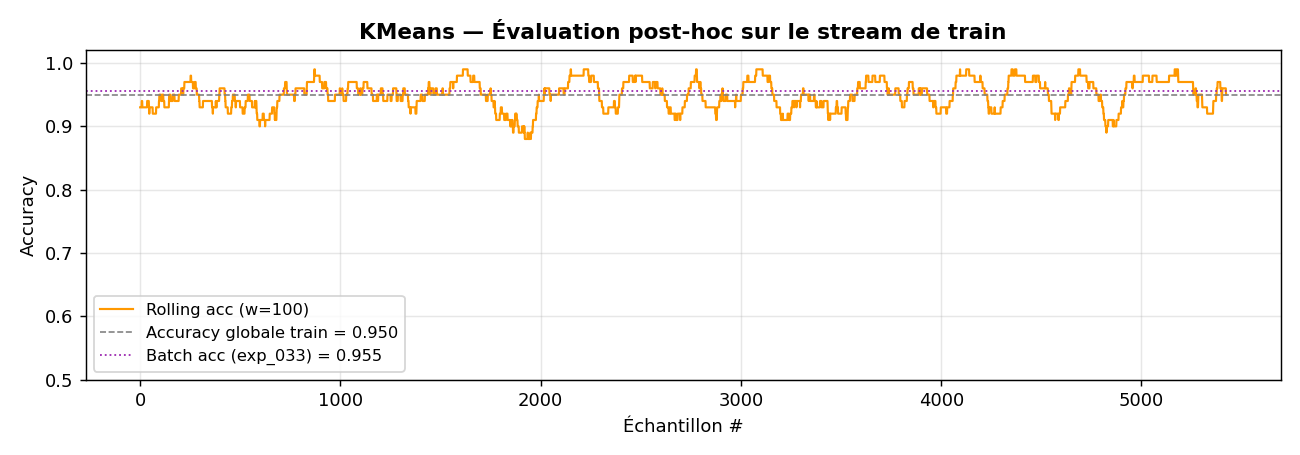

In [6]:
WINDOW = 100
rolling_acc = np.convolve((preds_arr == labels_arr).astype(float),
                           np.ones(WINDOW) / WINDOW, mode="valid")

fig, ax = plt.subplots(figsize=(10, 3.5), dpi=130)
ax.plot(rolling_acc, color=COLOR, linewidth=1.2, label=f"Rolling acc (w={WINDOW})")
ax.axhline(train_acc, color="gray", linestyle="--", linewidth=0.9,
           label=f"Accuracy globale train = {train_acc:.3f}")
if batch_metrics.get("accuracy"):
    ax.axhline(batch_metrics["accuracy"], color="#9C27B0", linestyle=":", linewidth=1,
               label=f"Batch acc (exp_033) = {batch_metrics['accuracy']:.3f}")
ax.set_xlabel("Échantillon #")
ax.set_ylabel("Accuracy")
ax.set_title(f"{MODEL_NAME} — Évaluation post-hoc sur le stream de train", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "prequential_rolling_acc.png", dpi=130)
display(Image(str(FIGURES_DIR / "prequential_rolling_acc.png")))

## Section 6 — Évaluation finale sur le test set

In [7]:
test_preds  = model.predict(X_test.astype(np.float32))
test_scores = model.anomaly_score(X_test.astype(np.float32))

test_acc = float(np.mean(test_preds == y_test.astype(int)))
test_f1  = f1_score(y_test.astype(int), test_preds, zero_division=0)
test_auc = roc_auc_score(y_test.astype(int), test_scores)

print(f"Test accuracy : {test_acc:.4f}")
print(f"Test AUC-ROC  : {test_auc:.4f}")
print(f"Test F1       : {test_f1:.4f}")

Test accuracy : 0.9550
Test AUC-ROC  : 0.9821
Test F1       : 0.7089


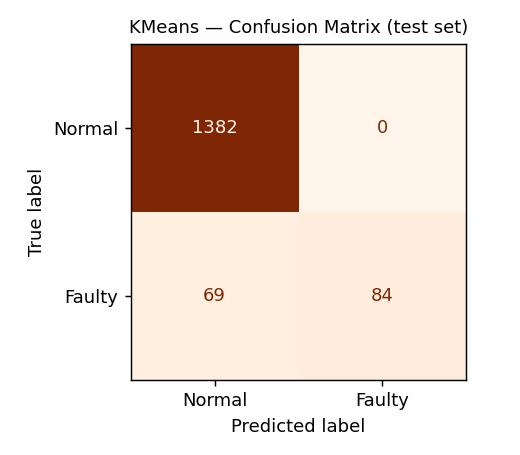

In [8]:
cm = confusion_matrix(y_test.astype(int), test_preds)
fig, ax = plt.subplots(figsize=(4, 3.5), dpi=130)
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Faulty"]).plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title(f"{MODEL_NAME} — Confusion Matrix (test set)", fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=130)
display(Image(str(FIGURES_DIR / "confusion_matrix.png")))

## Section 7 — Courbe ROC

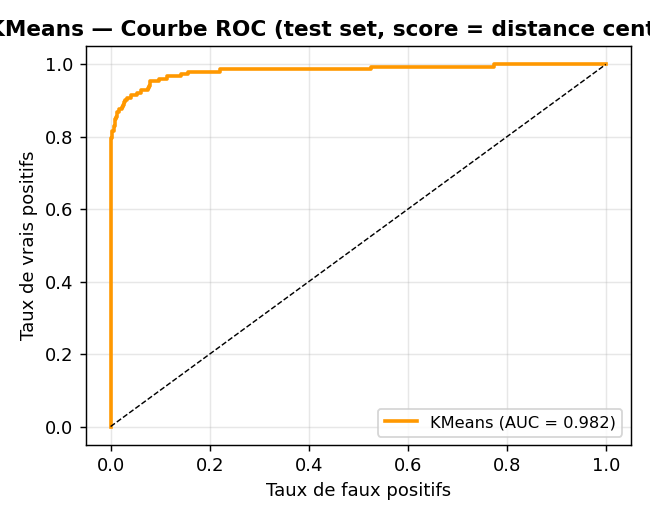

In [9]:
fpr, tpr, _ = roc_curve(y_test.astype(int), test_scores)

fig, ax = plt.subplots(figsize=(5, 4), dpi=130)
ax.plot(fpr, tpr, color=COLOR, linewidth=2, label=f"KMeans (AUC = {test_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title(f"{MODEL_NAME} — Courbe ROC (test set, score = distance centroïde)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "roc_curve.png", dpi=130)
display(Image(str(FIGURES_DIR / "roc_curve.png")))

## Section 8 — Espace des features (PCA 2D)

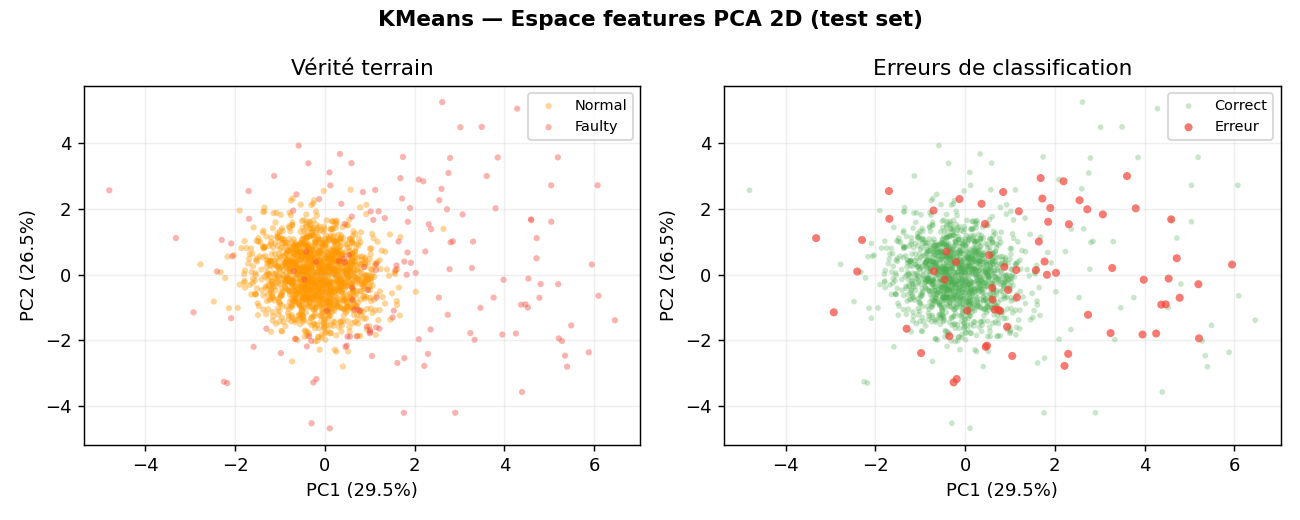

In [10]:
pca = PCA(n_components=2, random_state=SEED)
X_test_2d = pca.fit_transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=130)

for label, name, c in [(0, "Normal", COLOR), (1, "Faulty", "#F44336")]:
    mask = y_test.astype(int) == label
    axes[0].scatter(X_test_2d[mask, 0], X_test_2d[mask, 1], c=c, alpha=0.4, s=12, label=name, edgecolors="none")
axes[0].set_title("Vérité terrain")
axes[0].legend(fontsize=8)

correct = (test_preds == y_test.astype(int))
axes[1].scatter(X_test_2d[correct, 0],  X_test_2d[correct, 1],  c="#4CAF50", alpha=0.3, s=10, label="Correct",   edgecolors="none")
axes[1].scatter(X_test_2d[~correct, 0], X_test_2d[~correct, 1], c="#F44336", alpha=0.7, s=20, label="Erreur",    edgecolors="none")
axes[1].set_title("Erreurs de classification")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.grid(True, alpha=0.2)

fig.suptitle(f"{MODEL_NAME} — Espace features PCA 2D (test set)", fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pca_feature_space.png", dpi=130)
display(Image(str(FIGURES_DIR / "pca_feature_space.png")))

## Section 9 — Tableau récapitulatif

In [11]:
n_params = model.count_parameters()
ram_bytes = n_params * 4  # centroides FP32

print("=" * 55)
print(f"  Modèle          : {MODEL_NAME}")
print(f"  K={model.kmeans_.n_clusters}, méthode={model.k_method}")
print("-" * 55)
print(f"  Paramètres (centroides)  : {n_params}")
print(f"  RAM estimée              : {ram_bytes} B ({ram_bytes/1024:.1f} Ko)")
print(f"  Latence inférence        : {batch_metrics.get('inference_latency_ms', 'N/A')} ms")
print("-" * 55)
print(f"  Acc. exp_033 (batch)     : {batch_metrics.get('accuracy', 'N/A'):.4f}")
print(f"  Acc. stream train        : {train_acc:.4f}")
print(f"  Acc. test (post-fit)     : {test_acc:.4f}")
print(f"  AUC-ROC (test)           : {test_auc:.4f}")
print(f"  F1 (test)                : {test_f1:.4f}")
print("-" * 55)
budget_ok = ram_bytes <= 65536
print(f"  Budget RAM 64 Ko : {'✅ OK' if budget_ok else '❌ DÉPASSÉ'}")
print("=" * 55)

  Modèle          : KMeans
  K=3, méthode=silhouette
-------------------------------------------------------
  Paramètres (centroides)  : 12
  RAM estimée              : 48 B (0.0 Ko)
  Latence inférence        : 0.5692968402217957 ms
-------------------------------------------------------
  Acc. exp_033 (batch)     : 0.9550
  Acc. stream train        : 0.9497
  Acc. test (post-fit)     : 0.9550
  AUC-ROC (test)           : 0.9821
  F1 (test)                : 0.7089
-------------------------------------------------------
  Budget RAM 64 Ko : ✅ OK


## Section 10 — Contribution individuelle des variables

KMeans n'utilise pas de gradient → deux méthodes model-agnostiques :
- **Permutation importance** : permute une colonne, mesure la chute d'accuracy
- **Feature masking** : remplace une colonne par 0 (= moyenne Z-score), mesure la chute

In [12]:
def kmeans_predict_fn(X_np: np.ndarray) -> np.ndarray:
    return model.predict(X_np.astype(np.float32)).astype(float)

print("Calcul permutation importance (n_repeats=10)...")
perm_imp = permutation_importance(
    predict_fn=kmeans_predict_fn,
    X=X_test,
    y=y_test,
    feature_names=FEATURE_NAMES,
    n_repeats=10,
    random_state=SEED,
    threshold=0.5,
)

print("\nPermutation Importance :")
for feat, score in perm_imp.items():
    print(f"  {feat:15s}: {score:+.4f}")

Calcul permutation importance (n_repeats=10)...

Permutation Importance :
  temperature    : +0.0319
  pressure       : +0.0225
  vibration      : +0.0208
  humidity       : +0.0121


In [13]:
print("Calcul feature masking importance...")
mask_imp = feature_masking_importance(
    predict_fn=kmeans_predict_fn,
    X=X_test,
    y=y_test,
    feature_names=FEATURE_NAMES,
    mask_value=0.0,
    threshold=0.5,
)

print("\nFeature Masking Importance (mask=0.0) :")
for feat, score in mask_imp.items():
    print(f"  {feat:15s}: {score:+.4f}")

Calcul feature masking importance...

Feature Masking Importance (mask=0.0) :
  temperature    : +0.0195
  pressure       : +0.0169
  humidity       : +0.0156
  vibration      : +0.0150


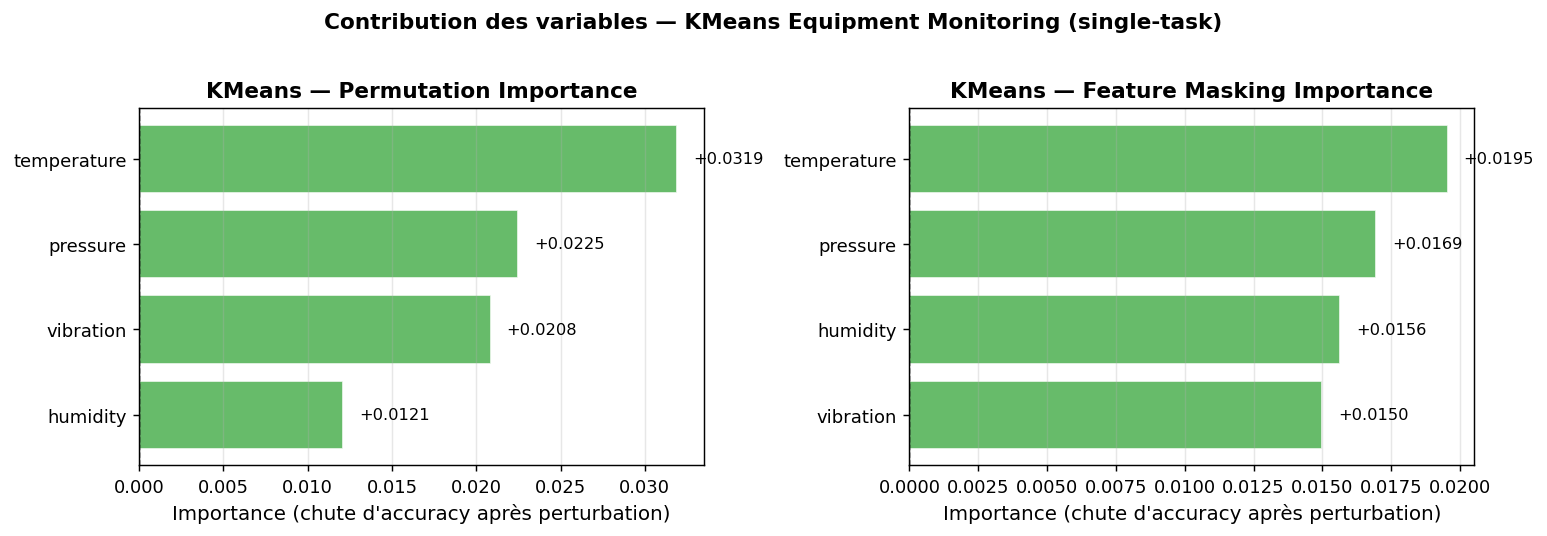

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=130)

_ = plot_feature_importance(
    perm_imp,
    title=f"{MODEL_NAME} — Permutation Importance",
    color=COLOR,
    ax=axes[0],
)
_ = plot_feature_importance(
    mask_imp,
    title=f"{MODEL_NAME} — Feature Masking Importance",
    color="#607D8B",
    ax=axes[1],
)

plt.suptitle("Contribution des variables — KMeans Equipment Monitoring (single-task)",
             fontweight="bold", fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "feature_importance_side_by_side.png", dpi=130, bbox_inches="tight")
display(Image(str(FIGURES_DIR / "feature_importance_side_by_side.png")))

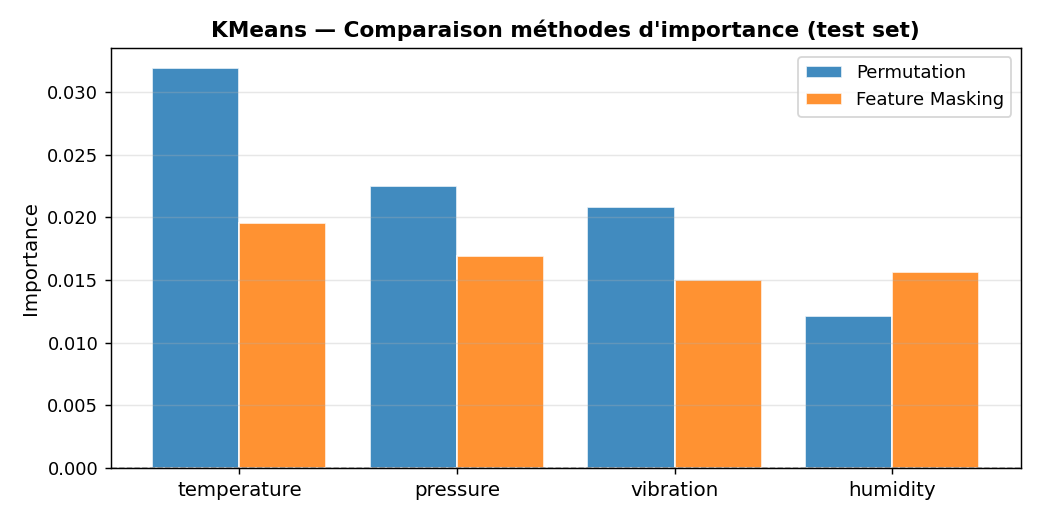

Variable la plus importante (permutation) : temperature
Variable la plus importante (masking)     : temperature
→ Les deux méthodes s'accordent.


In [15]:
fig = plot_feature_importance_comparison(
    {"Permutation": perm_imp, "Feature Masking": mask_imp},
    feature_names=FEATURE_NAMES,
    title=f"{MODEL_NAME} — Comparaison méthodes d'importance (test set)",
)
fig.savefig(FIGURES_DIR / "feature_importance_comparison.png", dpi=130)
display(Image(str(FIGURES_DIR / "feature_importance_comparison.png")))

top_perm = max(perm_imp, key=perm_imp.get)
top_mask = max(mask_imp, key=mask_imp.get)
print(f"Variable la plus importante (permutation) : {top_perm}")
print(f"Variable la plus importante (masking)     : {top_mask}")
if top_perm == top_mask:
    print("→ Les deux méthodes s'accordent.")
else:
    print("→ Divergence — la permutation randomise l'espace, le masking met à 0.")

In [16]:
importance_results = {
    "model": MODEL_NAME,
    "dataset": "equipment_monitoring",
    "scenario": "single_task_batch",
    "test_accuracy": test_acc,
    "test_auc_roc": test_auc,
    "train_stream_accuracy": train_acc,
    "permutation_importance": perm_imp,
    "feature_masking_importance": mask_imp,
}

out_path = EXP_DIR / "results" / "feature_importance.json"
with open(out_path, "w") as f:
    json.dump(importance_results, f, indent=2)

print(f"Résultats sauvegardés : {out_path}")
print("\n✅ Notebook KMeans single-task — terminé.")

Résultats sauvegardés : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_033_kmeans_monitoring_single_task/results/feature_importance.json

✅ Notebook KMeans single-task — terminé.
